# NBT SmallSet Data Inspection

Professional first-pass exploratory data analysis for the NBT SmallSet theatre operations dataset.

## Inspection goals

- Understand dataset size, columns, and data types.
- Check missing values, duplicates, and suspicious records.
- Inspect numeric columns such as age, planned duration, and operation length.
- Inspect categorical columns such as theatre room, procedure, priority, ASA score, and anaesthetic type.
- Check whether time columns look consistent and usable for later preprocessing.

In [142]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Load the data

In [143]:
data_path = Path("../data/NBT-SmallSet.xlsx")

nbt_smallset_df = pd.read_excel(data_path, sheet_name="Sheet1")

In [144]:
pd.concat([nbt_smallset_df.head(3), nbt_smallset_df.tail(3)])

,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
0,PLASTIC MINOR 2,11,TH 26 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mins/day case/LA/ 5mm WLE R abdo scar )(in-situ MM) ....,60.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00,19.00,2.00,68.00,1.00,P2,LA (Surgeon),A000012,C4090155,NaN
1,PARKVIEW TH02,11,TH2 (2SD) A Harris (Urology),2.00,M653,Endoscopic resection of prostate NEC,TURP DC GA P3 Xray no Comments = Retention doing ISC....,120.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN,92.00,1.00,72.00,2.00,P3,LA (Surgeon),C7016369,C7016369,C7042030
2,BRUNEL TH 11,11,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),2.00,Z724,Carpal bone NEC,Right Trapeziectomy +/- LRTI 90 mins....,120.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN,60.00,2.00,70.00,2.00,P4,GA,C7136326,C7136326,7038820
14915,PARKVIEW TH02,11,"TH2 (2SD) S,Bolomytis (Urology)",2.00,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,m45.5 Cystoscopy and bladder biopsies DC....,60.00,00:48:00,00:48:00,00:45:00,00:54:00,NaN,00:00:00,NaN,72.00,1.00,76.00,3.00,P2,GA,C7477113,C7477113,C3467499
14916,PLASTIC MINOR 1,11,TH25 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,90mins/day case/LA/ bcc right nasal dorsum side wall excise and local flap/FTSG staff grade PSOP P2 within 2-...,90.00,00:17:00,00:17:00,00:36:00,00:01:00,10:28:00,00:23:00,00:28:00,66.00,1.00,63.00,2.00,P2,LA (Surgeon),A000012,C6156511,NaN
14917,IR LAB 4,12,IR4 Morning / R Consultant (Radiology),2.00,M131,Percutaneous needle biopsy of lesion of kidney,33mm right lower pole tumour being worked up for cryoablation. For histological confirmation....,45.00,00:00:00,00:00:00,00:23:00,00:32:00,10:41:00,00:33:00,NaN,33.00,1.00,72.00,NaN,P2,LA (Surgeon),A000013,C4717339,NaN


## 2. Basic structure

In [145]:
rows, columns = nbt_smallset_df.shape
print(f"Rows: {rows:,}")
print(f"Columns: {columns:,}")


Rows: 14,918
Columns: 24


In [146]:
column_overview = pd.DataFrame({
    "column": nbt_smallset_df.columns,
    "dtype": nbt_smallset_df.dtypes.astype(str).values,
    "non_null": nbt_smallset_df.notna().sum().values,
    "missing": nbt_smallset_df.isna().sum().values,
    "missing_pct": (nbt_smallset_df.isna().mean() * 100).round(2).values,
    "unique_values": nbt_smallset_df.nunique(dropna=True).values,
})

column_overview.sort_values("missing_pct", ascending=False)

,column,dtype,non_null,missing,missing_pct,unique_values
14,recovery_time,object,1768,13150,88.15,60
19,PriorityLevelCode,str,6355,8563,57.40,4
23,theat_anae_1_national_code,object,9512,5406,36.24,323
18,ASAScore,float64,13664,1254,8.41,7
20,anaesthetic_desc,str,14174,744,4.99,7
12,out_of_theatre,object,14321,597,4.00,1193
7,ExpectedDurationMins,float64,14704,214,1.43,189
22,theat_surg_1_national_code,object,14803,115,0.77,390
4,actual_proc_1_procedure_code,str,14828,90,0.60,1038
5,ProcedureDescription,str,14828,90,0.60,1038


In [147]:
nbt_smallset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14918 entries, 0 to 14917
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   TheatreRoom                   14918 non-null  str    
 1   admission_type                14916 non-null  object 
 2   SessionIDdesc                 14918 non-null  str    
 3   intended_management           14913 non-null  float64
 4   actual_proc_1_procedure_code  14828 non-null  str    
 5   ProcedureDescription          14828 non-null  str    
 6   theatre_notes                 14842 non-null  str    
 7   ExpectedDurationMins          14704 non-null  float64
 8   into_theatre                  14918 non-null  object 
 9   anaesthetic_start_time        14918 non-null  object 
 10  incision                      14862 non-null  object 
 11  closure                       14845 non-null  object 
 12  out_of_theatre                14321 non-null  object 
 13  operation_en

## 3. Data quality checks

In [148]:
missing_summary = (
    nbt_smallset_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(nbt_smallset_df) * 100).round(2)
missing_summary.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
recovery_time,13150,88.15
PriorityLevelCode,8563,57.40
theat_anae_1_national_code,5406,36.24
ASAScore,1254,8.41
anaesthetic_desc,744,4.99
out_of_theatre,597,4.00
ExpectedDurationMins,214,1.43
theat_surg_1_national_code,115,0.77
actual_proc_1_procedure_code,90,0.60
ProcedureDescription,90,0.60


In [149]:
duplicate_count = nbt_smallset_df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

nbt_smallset_df[nbt_smallset_df.duplicated(keep=False)].sort_values(nbt_smallset_df.columns.tolist()).head(20)

Exact duplicate rows: 6


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
5305,CATH LAB 05,24,C Consultant (Cardiology) Elective & Emergency,1.00,K636,Coronary arteriography NEC,83 Direct admission from Echo department with Decompensated HF secondary to severe AS Bilateral Pleural effusion...,54.00,00:35:00,00:35:00,00:51:00,00:06:00,17:29:00,00:13:00,NaN,38.00,1.00,83.00,NaN,NaN,LA (Surgeon),C3289073,A000003,NaN
5382,CATH LAB 05,24,C Consultant (Cardiology) Elective & Emergency,1.00,K636,Coronary arteriography NEC,83 Direct admission from Echo department with Decompensated HF secondary to severe AS Bilateral Pleural effusion...,54.00,00:35:00,00:35:00,00:51:00,00:06:00,17:29:00,00:13:00,NaN,38.00,1.00,83.00,NaN,NaN,LA (Surgeon),C3289073,A000003,NaN
4960,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"11:30- P2, Excision biopsy lesion ?MM left back, LA/DC....",60.00,00:54:00,00:54:00,00:01:00,00:10:00,11:13:00,00:11:00,00:13:00,17.00,2.00,31.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
5002,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"11:30- P2, Excision biopsy lesion ?MM left back, LA/DC....",60.00,00:54:00,00:54:00,00:01:00,00:10:00,11:13:00,00:11:00,00:13:00,17.00,2.00,31.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
12096,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"15:30 - P2, Excision ?Haemangioma ?Bcc ?Amelanotic MM and direct closure leftupper forehead, LA/DC....",60.00,00:29:00,00:29:00,00:29:00,00:55:00,17:00:00,00:55:00,NaN,26.00,2.00,63.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
12116,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"15:30 - P2, Excision ?Haemangioma ?Bcc ?Amelanotic MM and direct closure leftupper forehead, LA/DC....",60.00,00:29:00,00:29:00,00:29:00,00:55:00,17:00:00,00:55:00,NaN,26.00,2.00,63.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
4967,PLASTIC MINOR 2,11,TH26 (2SD) P Consultant (Plastic Surgery),2.00,NaN,NaN,"08:30 - Excision ?MM left forarm, LA/DC....",30.00,00:39:00,00:39:00,00:39:00,00:39:00,09:39:00,00:39:00,00:40:00,0.00,2.00,73.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
5045,PLASTIC MINOR 2,11,TH26 (2SD) P Consultant (Plastic Surgery),2.00,NaN,NaN,"08:30 - Excision ?MM left forarm, LA/DC....",30.00,00:39:00,00:39:00,00:39:00,00:39:00,09:39:00,00:39:00,00:40:00,0.00,2.00,73.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
10056,PLASTIC MINOR 2,11,TH26 2SD KPI P Consultant (Plastic Surgery),2.00,NaN,NaN,Excision ?SCC left forearm 30 minutes LA....,30.00,00:15:00,00:15:00,00:18:00,00:38:00,15:46:00,00:40:00,00:46:00,25.00,2.00,85.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
10152,PLASTIC MINOR 2,11,TH26 2SD KPI P Consultant (Plastic Surgery),2.00,NaN,NaN,Excision ?SCC left forearm 30 minutes LA....,30.00,00:15:00,00:15:00,00:18:00,00:38:00,15:46:00,00:40:00,00:46:00,25.00,2.00,85.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN


In [150]:
text_columns = nbt_smallset_df.select_dtypes(include="object").columns

blank_like_summary = []
for column in text_columns:
    cleaned = nbt_smallset_df[column].astype("string").str.strip()
    blank_like_summary.append({
        "column": column,
        "empty_strings": (cleaned == "").sum(),
        "single_dots": (cleaned == ".").sum(),
        "unique_values": cleaned.nunique(dropna=True),
    })

pd.DataFrame(blank_like_summary).sort_values(["single_dots", "empty_strings"], ascending=False)

C:\Users\Alaa\AppData\Local\Temp\ipykernel_114292\3100953441.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = nbt_smallset_df.select_dtypes(include="object").columns


,column,empty_strings,single_dots,unique_values
5,theatre_notes,0,2488,9765
0,TheatreRoom,0,0,45
1,admission_type,0,0,16
2,SessionIDdesc,0,0,2281
3,actual_proc_1_procedure_code,0,0,1038
4,ProcedureDescription,0,0,1038
6,into_theatre,0,0,69
7,anaesthetic_start_time,0,0,69
8,incision,0,0,67
9,closure,0,0,69


## 4. Numeric variable inspection

In [151]:
numeric_columns = [
    "ExpectedDurationMins",
    "operation_length_mins",
    "age_at_operation",
    "ASAScore",
    "intended_management",
    "sex_national_code",
]

nbt_smallset_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ExpectedDurationMins,14704.00,98.28,88.53,0.00,60.00,60.00,120.00,1415.00
operation_length_mins,14845.00,97.89,92.50,0.00,39.00,70.00,124.00,1017.00
age_at_operation,14872.00,57.07,19.59,16.00,40.00,59.00,73.00,107.00
ASAScore,13664.00,2.25,0.83,0.00,2.00,2.00,3.00,6.00
intended_management,14913.00,1.56,0.85,1.00,1.00,1.00,2.00,8.00
sex_national_code,14872.00,1.53,0.50,1.00,1.00,2.00,2.00,2.00


In [152]:
numeric_quality_checks = pd.DataFrame({
    "zero_expected_duration": [(nbt_smallset_df["ExpectedDurationMins"] == 0).sum()],
    "zero_operation_length": [(nbt_smallset_df["operation_length_mins"] == 0).sum()],
    "age_under_18": [(nbt_smallset_df["age_at_operation"] < 18).sum()],
    "age_over_100": [(nbt_smallset_df["age_at_operation"] > 100).sum()],
    "asa_score_zero": [(nbt_smallset_df["ASAScore"] == 0).sum()],
    "asa_score_over_5": [(nbt_smallset_df["ASAScore"] > 5).sum()],
})

numeric_quality_checks.T.rename(columns={0: "row_count"})

,row_count
zero_expected_duration,62
zero_operation_length,9
age_under_18,103
age_over_100,2
asa_score_zero,1
asa_score_over_5,21


In [153]:
duration_df = nbt_smallset_df.copy()
duration_df["duration_error_mins"] = duration_df["operation_length_mins"] - duration_df["ExpectedDurationMins"]

duration_df[["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]].describe().T

,count,mean,std,min,25%,50%,75%,max
ExpectedDurationMins,14704.00,98.28,88.53,0.00,60.00,60.00,120.00,1415.00
operation_length_mins,14845.00,97.89,92.50,0.00,39.00,70.00,124.00,1017.00
duration_error_mins,14632.00,-0.15,69.13,-1399.00,-32.00,-8.00,22.00,970.00


In [154]:
duration_df[
    ["TheatreRoom", "ProcedureDescription", "ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]
].sort_values("duration_error_mins", ascending=False).head(10)

,TheatreRoom,ProcedureDescription,ExpectedDurationMins,operation_length_mins,duration_error_mins
5582,IR LAB 3,Open embolectomy of cerebral artery,0.00,970.00,970.00
8103,BRUNEL TH 06,Unspecified opening of cranium,150.00,1017.00,867.00
9121,BRUNEL TH 07,Posterior fusion of joint of cervical spine NEC,180.00,971.00,791.00
8273,GYNAE TH 01,Elective lower uterine segment caesarean delivery,60.00,790.00,730.00
2317,BRUNEL TH 06,Other specified extirpation of lesion of meninges of brain,150.00,779.00,629.00
6969,BRUNEL TH 01,Debridement of burnt skin of head or neck,60.00,680.00,620.00
9522,BRUNEL TH 04,Shaft of tibia NEC,90.00,655.00,565.00
13037,BRUNEL TH 04,Left sided operation,60.00,586.00,526.00
13448,BRUNEL TH 09,Primary total prosthetic replacement of hip joint using cement,120.00,642.00,522.00
13504,BRUNEL TH 09,Primary total prosthetic replacement of hip joint using cement,120.00,642.00,522.00


## 5. Categorical variable inspection

In [155]:
categorical_columns = [
    "TheatreRoom",
    "admission_type",
    "SessionIDdesc",
    "actual_proc_1_procedure_code",
    "ProcedureDescription",
    "PriorityLevelCode",
    "anaesthetic_desc",
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

pd.DataFrame({
    "unique_values": nbt_smallset_df[categorical_columns].nunique(dropna=True),
    "missing_count": nbt_smallset_df[categorical_columns].isna().sum(),
    "missing_pct": (nbt_smallset_df[categorical_columns].isna().mean() * 100).round(2),
}).sort_values("unique_values", ascending=False)

,unique_values,missing_count,missing_pct
SessionIDdesc,2288,0,0.00
actual_proc_1_procedure_code,1038,90,0.60
ProcedureDescription,1038,90,0.60
theat_surg_1_national_code,390,115,0.77
theat_anae_1_national_code,323,5406,36.24
listing_cons_code,283,77,0.52
TheatreRoom,45,0,0.00
admission_type,16,2,0.01
anaesthetic_desc,7,744,4.99
PriorityLevelCode,4,8563,57.40


In [156]:
for column in ["TheatreRoom", "ProcedureDescription", "PriorityLevelCode", "anaesthetic_desc", "ASAScore"]:
    print(f"\nTop values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for TheatreRoom


,count
TheatreRoom,
BRUNEL TH 05,706
PLASTIC MINOR 1,651
IR LAB 1,631
GYNAE TH 02,621
IR LAB 2,551
CATH LAB 05,524
PLASTIC MINOR 2,523
BRUNEL TH 03,520
BRUNEL TH 06,516



Top values for ProcedureDescription


,count
ProcedureDescription,
Unspecified other excision of lesion of skin,1423
Elective lower uterine segment caesarean delivery,633
Other specified general anaesthetic,326
Coronary arteriography NEC,278
Lower uterine segment caesarean delivery NEC,259
Maintenance of drainage tube of kidney,223
Debridement of skin NEC,215
Total cholecystectomy NEC,181
Percutaneous transluminal angioplasty of artery,178



Top values for PriorityLevelCode


,count
PriorityLevelCode,
NaN,8563
P2,3714
P3,1521
P4,1119
P1,1



Top values for anaesthetic_desc


,count
anaesthetic_desc,
GA,8192
LA (Surgeon),4113
NaN,744
Neuraxial Block,655
No Anaesthetic,460
Sedation,307
GA and Regional,307
Regional Only,140



Top values for ASAScore


,count
ASAScore,
2.00,6219
3.00,4241
1.00,2424
NaN,1254
4.00,723
5.00,35
6.00,21
0.00,1


## 6. Decode `actual_proc_1_procedure_code` using OPCS structure

`actual_proc_1_procedure_code` appears to use NHS OPCS-4 procedure codes. OPCS-4 codes are usually four characters: one chapter letter followed by three digits. The first letter gives the broad chapter/body-system category, the first three characters give the procedure category, and the fourth digit gives the subcategory/rubric.

Important: this section decodes the code structure and broad OPCS chapter. For the official full title of every code, use the NHS Classifications Browser or an official OPCS lookup. In this dataset, `ProcedureDescription` already provides the procedure title supplied with the data.

In [157]:
opcs_chapter_map = {
    "A": "Nervous System",
    "B": "Endocrine System and Breast",
    "C": "Eye",
    "D": "Ear",
    "E": "Respiratory Tract",
    "F": "Mouth",
    "G": "Upper Digestive System",
    "H": "Lower Digestive System",
    "J": "Other Abdominal Organs, Principally Digestive",
    "K": "Heart",
    "L": "Arteries and Veins",
    "M": "Urinary",
    "N": "Male Genital Organs",
    "O": "Overflow OPCS code - chapter requires official OPCS lookup",
    "P": "Lower Female Genital Tract",
    "Q": "Upper Female Genital Tract",
    "R": "Female Genital Tract Associated with Pregnancy, Childbirth and the Puerperium",
    "S": "Skin",
    "T": "Soft Tissue",
    "U": "Diagnostic Imaging, Testing and Rehabilitation",
    "V": "Bones and Joints of Skull and Spine",
    "W": "Other Bones and Joints",
    "X": "Miscellaneous Operations",
    "Y": "Subsidiary Classification of Methods of Operation",
    "Z": "Subsidiary Classification of Sites of Operation",
}

def decode_opcs_code(code):
    if pd.isna(code):
        return pd.Series({
            "opcs_code_clean": pd.NA,
            "opcs_code_dotted": pd.NA,
            "opcs_chapter_letter": pd.NA,
            "opcs_chapter_name": pd.NA,
            "opcs_category_code": pd.NA,
            "opcs_subcategory_digit": pd.NA,
            "opcs_code_format_valid": False,
        })

    code_clean = re.sub(r"[^A-Z0-9]", "", str(code).upper().strip())
    format_valid = bool(re.fullmatch(r"[A-Z][0-9]{3}", code_clean))

    chapter_letter = code_clean[0] if len(code_clean) >= 1 else pd.NA
    category_code = code_clean[:3] if len(code_clean) >= 3 else pd.NA
    subcategory_digit = code_clean[3] if len(code_clean) >= 4 else pd.NA
    code_dotted = f"{code_clean[:3]}.{code_clean[3]}" if format_valid else pd.NA

    return pd.Series({
        "opcs_code_clean": code_clean if code_clean else pd.NA,
        "opcs_code_dotted": code_dotted,
        "opcs_chapter_letter": chapter_letter,
        "opcs_chapter_name": opcs_chapter_map.get(chapter_letter, pd.NA),
        "opcs_category_code": category_code,
        "opcs_subcategory_digit": subcategory_digit,
        "opcs_code_format_valid": format_valid,
    })


opcs_info_df = nbt_smallset_df["actual_proc_1_procedure_code"].apply(decode_opcs_code)
nbt_opcs_df = pd.concat([nbt_smallset_df, opcs_info_df], axis=1)

nbt_opcs_df[[
    "actual_proc_1_procedure_code",
    "ProcedureDescription",
    "opcs_code_dotted",
    "opcs_chapter_letter",
    "opcs_chapter_name",
    "opcs_category_code",
    "opcs_subcategory_digit",
    "opcs_code_format_valid",
]].head(20)

,actual_proc_1_procedure_code,ProcedureDescription,opcs_code_dotted,opcs_chapter_letter,opcs_chapter_name,opcs_category_code,opcs_subcategory_digit,opcs_code_format_valid
0,S069,Unspecified other excision of lesion of skin,S06.9,S,Skin,S06,9,True
1,M653,Endoscopic resection of prostate NEC,M65.3,M,Urinary,M65,3,True
2,Z724,Carpal bone NEC,Z72.4,Z,Subsidiary Classification of Sites of Operation,Z72,4,True
3,S069,Unspecified other excision of lesion of skin,S06.9,S,Skin,S06,9,True
4,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,M45.5,M,Urinary,M45,5,True
5,Z779,Tibia NEC,Z77.9,Z,Subsidiary Classification of Sites of Operation,Z77,9,True
6,G215,Insertion of stent into oesophagus NEC,G21.5,G,Upper Digestive System,G21,5,True
7,T962,Excision of lesion of soft tissue NEC,T96.2,T,Soft Tissue,T96,2,True
8,A642,Primary repair of peripheral nerve NEC,A64.2,A,Nervous System,A64,2,True
9,Y808,Other specified general anaesthetic,Y80.8,Y,Subsidiary Classification of Methods of Operation,Y80,8,True


In [158]:
opcs_summary = pd.DataFrame({
    "missing_count": opcs_info_df.isna().sum(),
    "missing_pct": (opcs_info_df.isna().mean() * 100).round(2),
    "unique_values": opcs_info_df.nunique(dropna=True),
})

opcs_summary

,missing_count,missing_pct,unique_values
opcs_code_clean,90,0.60,1038
opcs_code_dotted,90,0.60,1038
opcs_chapter_letter,90,0.60,25
opcs_chapter_name,90,0.60,25
opcs_category_code,90,0.60,553
opcs_subcategory_digit,90,0.60,9
opcs_code_format_valid,0,0.00,2


In [159]:
nbt_opcs_df["opcs_chapter_name"].value_counts(dropna=False).to_frame("case_count")

,case_count
opcs_chapter_name,
Skin,2256
Urinary,1723
Other Bones and Joints,1552
"Female Genital Tract Associated with Pregnancy, Childbirth and the Puerperium",1110
Arteries and Veins,1021
Soft Tissue,888
Subsidiary Classification of Methods of Operation,790
Upper Female Genital Tract,739
Nervous System,733


In [160]:
opcs_category_summary = (
    nbt_opcs_df.groupby([
        "opcs_chapter_name",
        "opcs_category_code",
        "opcs_code_dotted",
        "ProcedureDescription",
    ], dropna=False)
    .size()
    .rename("case_count")
    .reset_index()
    .sort_values("case_count", ascending=False)
)

opcs_category_summary.head(50)

,opcs_chapter_name,opcs_category_code,opcs_code_dotted,ProcedureDescription,case_count
645,Skin,S06,S06.9,Unspecified other excision of lesion of skin,1423
221,"Female Genital Tract Associated with Pregnancy, Childbirth and the Puerperium",R17,R17.2,Elective lower uterine segment caesarean delivery,633
805,Subsidiary Classification of Methods of Operation,Y80,Y80.8,Other specified general anaesthetic,326
250,Heart,K63,K63.6,Coronary arteriography NEC,278
222,"Female Genital Tract Associated with Pregnancy, Childbirth and the Puerperium",R18,R18.2,Lower uterine segment caesarean delivery NEC,259
977,Urinary,M16,M16.2,Maintenance of drainage tube of kidney,223
674,Skin,S57,S57.1,Debridement of skin NEC,215
473,"Other Abdominal Organs, Principally Digestive",J18,J18.3,Total cholecystectomy NEC,181
61,Arteries and Veins,L71,L71.1,Percutaneous transluminal angioplasty of artery,178
1018,Urinary,M61,M61.1,Total excision of prostate and capsule of prostate,173


In [161]:
nbt_opcs_df.loc[
    ~nbt_opcs_df["opcs_code_format_valid"] | nbt_opcs_df["opcs_chapter_name"].isna(),
    ["actual_proc_1_procedure_code", "ProcedureDescription", "opcs_code_clean", "opcs_chapter_letter"],
].drop_duplicates().head(50)

,actual_proc_1_procedure_code,ProcedureDescription,opcs_code_clean,opcs_chapter_letter
2078,NaN,NaN,NaN,NaN


## 7. Extract information from `SessionIDdesc`

`SessionIDdesc` is a semi-structured text column. It does not follow one perfect format, so we extract only the parts that appear repeatedly and then review the results before using them.

In [162]:
nbt_smallset_df["SessionIDdesc"].value_counts().head(30).to_frame("count")

,count
SessionIDdesc,
TH 5 A Consultant (Non Specific) Emergency,686
C Consultant (Cardiology) Elective & Emergency,660
TH2 EMERGENCY O Consultant (Obs & Gynae),605
TH 6 A Consultant (Non Specific) Emergency,505
TH 2 (2SD) P Consultant (Plastic Surgery),387
IR1 Morning / R Consultant (Radiology),344
TH25 AM P Consultant (Plastic Surgery),288
TH25 PM P Consultant (Plastic Surgery),283
TH 3 (3SD) T Consultant (Trauma and Orthopaedics),279


In [163]:
def extract_session_info(session_desc):
    """Extract reliable fields from a messy SessionIDdesc value."""
    if pd.isna(session_desc):
        return pd.Series({
            "session_room": pd.NA,
            "session_duration_code": pd.NA,
            "session_period": pd.NA,
            "session_urgency": pd.NA,
            "session_specialty": pd.NA,
            "session_consultant_or_team": pd.NA,
        })

    text = re.sub(r"\s+", " ", str(session_desc).strip())
    upper_text = text.upper()

    room_match = re.search(
        r"\b(TTH\s*\d+|TH\s*\d+(?=AM|PM)|TH\s*\d+[A-Z]?|THB|IR\s*\d+(?=ALL)|IR\s*\d+|IR\s*COVER|HYBRID|HYBRDI|CATH\s*LAB\s*\d+|PACING\s*R(?:OO)?M|FLUORO\s*\d+|CT\s*\d+|THEATRE\s*\d+|CEPOD)",
        text,
        flags=re.IGNORECASE,
    )
    
    duration_match = re.search(r"\b([123]SD)\b", upper_text)
    period_match = re.search(r"\b(ALL\s*DAY|MORNING|AFTERNOON|AM/PM|PM/EVE|AM|PM|EVE)\b|(?<=\d)(AM|PM)", upper_text)
    urgency_match = re.search(r"\b(EMERGENCY|EMERGENY|ELECTIVE|TRAUMA|FLEXI)\b", upper_text)
    specialty_matches = re.findall(r"\(([^()]*)\)", text)

    specialty = specialty_matches[-1].strip() if specialty_matches else pd.NA
    if pd.isna(specialty):
        specialty_fallback_match = re.search(
            r"\b(OBSTETRICS AND GYNAECOLOGY|OBS AND GYNAE|GYNAECOLOGY|RADIOLOGY|TRAUMA AND ORTHOPAEDICS|TRAUMA & ORTHOPAEDICS|ORTHOPAEDICS|OBSTETRICS|CARDIOLOGY|UROLOGY|ANAESTHETICS|GENERAL SURGERY|PLASTIC SURGERY|VASCULAR SURGERY|NEUROSURGERY|BREAST SURGERY|BARIATRICS|NEPHROLOGY)\b",
            upper_text,
        )
        specialty = specialty_fallback_match.group(1).title().replace(" And ", " and ").replace("&", "and") if specialty_fallback_match else pd.NA
    if isinstance(specialty, str):
        specialty = re.sub(r"\s+", " ", specialty.replace("&", "and")).strip()

    consultant_text = text
    consultant_text = re.sub(r"\([^()]*\)", " ", consultant_text)
    consultant_text = re.sub(r"\b(TTH\s*\d+|TH\s*\d+(?=AM|PM)|TH\s*\d+[A-Z]?|THB|IR\s*\d+(?=ALL)|IR\s*\d+|IR\s*COVER|HYBRID|HYBRDI|CATH\s*LAB\s*\d+|PACING\s*R(?:OO)?M|FLUORO\s*\d+|CT\s*\d+|THEATRE\s*\d+|CEPOD)", " ", consultant_text, flags=re.IGNORECASE)
    consultant_text = re.sub(r"\b([123]SD|ALL\s*DAY|MORNING|AFTERNOON|AM/PM|PM/EVE|AM|PM|EVE|EMERGENCY|EMERGENY|ELECTIVE|TRAUMA|FLEXI)\b|(?<=\d)(AM|PM)", " ", consultant_text, flags=re.IGNORECASE)
    consultant_text = re.sub(r"[/,-]+", " ", consultant_text)
    consultant_text = re.sub(r"\s+", " ", consultant_text).strip()

    return pd.Series({
        "session_room": re.sub(r"\s+", "", room_match.group(1)).upper().replace("TTH", "TH").replace("HYBRDI", "HYBRID").replace("PACINGRM", "PACING_ROOM").replace("PACINGROOM", "PACING_ROOM") if room_match else pd.NA,
        "session_duration_code": duration_match.group(1) if duration_match else pd.NA,
        "session_period": (period_match.group(1) or period_match.group(2)).replace("ALLDAY", "ALL DAY").title() if period_match else pd.NA,
        "session_urgency": urgency_match.group(1).replace("EMERGENY", "EMERGENCY").title() if urgency_match else pd.NA,
        "session_specialty": specialty,
        "session_consultant_or_team": consultant_text if consultant_text else pd.NA,
    })


session_info_df = nbt_smallset_df["SessionIDdesc"].apply(extract_session_info)
nbt_session_df = pd.concat([nbt_smallset_df, session_info_df], axis=1)

nbt_session_df[
    [
        "SessionIDdesc",
        "session_room",
        "session_duration_code",
        "session_period",
        "session_urgency",
        "session_specialty",
        "session_consultant_or_team",
    ]
].head(20)

,SessionIDdesc,session_room,session_duration_code,session_period,session_urgency,session_specialty,session_consultant_or_team
0,TH 26 AM P Consultant (Plastic Surgery),TH26,NaN,Am,NaN,Plastic Surgery,P Consultant
1,TH2 (2SD) A Harris (Urology),TH2,2SD,NaN,NaN,Urology,A Harris
2,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),TH11,2SD,NaN,Trauma,Trauma and Orthopaedics,Mr A Kiszely
3,TH 26 PM P Consultant (Plastic Surgery),TH26,NaN,Pm,NaN,Plastic Surgery,P Consultant
4,TH15 (3SD) H GILBERT (Urology),TH15,3SD,NaN,NaN,Urology,H GILBERT
5,TH23 (3SD) Mr J Murray (Trauma and Orthopaedics),TH23,3SD,NaN,Trauma,Trauma and Orthopaedics,Mr J Murray
6,IR1 Morning / R Consultant (Radiology),IR1,NaN,Morning,NaN,Radiology,R Consultant
7,TH11 (EVE) Mr T Chapman (Plastic Surgery),TH11,NaN,Eve,NaN,Plastic Surgery,Mr T Chapman
8,TH 2 (2SD) P Consultant (Plastic Surgery),TH2,2SD,NaN,NaN,Plastic Surgery,P Consultant
9,TH12 (2SD) F.Boriani (Plastic Surgery),TH12,2SD,NaN,NaN,Plastic Surgery,F.Boriani


In [164]:
session_extraction_quality = pd.DataFrame({
    "missing_count": session_info_df.isna().sum(),
    "missing_pct": (session_info_df.isna().mean() * 100).round(2),
    "unique_values": session_info_df.nunique(dropna=True),
})

session_extraction_quality.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct,unique_values
session_period,9876,66.20,8
session_urgency,8541,57.25,4
session_duration_code,8139,54.56,3
session_room,837,5.61,42
session_specialty,27,0.18,51
session_consultant_or_team,22,0.15,475


In [165]:
nbt_session_df[
    [
        "SessionIDdesc",
        "session_room",
        "session_duration_code",
        "session_period",
        "session_urgency",
        "session_specialty",
        "session_consultant_or_team",
    ]
].drop_duplicates().sample(30, random_state=42)

,SessionIDdesc,session_room,session_duration_code,session_period,session_urgency,session_specialty,session_consultant_or_team
4804,Th 9 A Consultant (Non Specific),TH9,NaN,NaN,NaN,Non Specific,A Consultant
3338,Hybrid (PM/EVE) A WEALE (Vascular Surgery),HYBRID,NaN,Pm/Eve,NaN,Vascular Surgery,A WEALE
2515,TH18 (2SD) J PRESHAW (Gynaecology),TH18,2SD,NaN,NaN,Gynaecology,J PRESHAW
3614,TH24 (2SD) T Consultant (Trauma and Orthopaedics),TH24,2SD,NaN,Trauma,Trauma and Orthopaedics,T Consultant
2176,TH7 (PM) C Charalambides (Neurosurgery),TH7,NaN,Pm,NaN,Neurosurgery,C Charalambides
1016,Mr A Riddick (Trauma and Orthopaedics),NaN,NaN,NaN,Trauma,Trauma and Orthopaedics,Mr A Riddick
7915,TH2 PM O Consultant (Obstetrics and Gynaecology),TH2,NaN,Pm,NaN,Obstetrics and Gynaecology,O Consultant
365,TH17 (3SD) C Wong (Upper GI),TH17,3SD,NaN,NaN,Upper GI,C Wong
5687,TH1 AM ELECTIVE / R Ion,TH1,NaN,Am,Elective,NaN,R Ion
12663,IR1 All Day / R Consultant (Radiology),IR1,NaN,All Day,NaN,Radiology,R Consultant


## 7. Time column inspection

These columns look like time-of-day or duration values. Before modeling or cleaning, check whether they parse consistently.

In [166]:
time_columns = [
    "into_theatre",
    "anaesthetic_start_time",
    "incision",
    "closure",
    "out_of_theatre",
    "operation_end_time",
    "recovery_time",
]

time_parse_summary = []
for column in time_columns:
    parsed = pd.to_timedelta(nbt_smallset_df[column].astype("string"), errors="coerce")
    time_parse_summary.append({
        "column": column,
        "non_null_original": nbt_smallset_df[column].notna().sum(),
        "parsed_successfully": parsed.notna().sum(),
        "parse_failed_non_null": (nbt_smallset_df[column].notna() & parsed.isna()).sum(),
        "zero_times": (parsed == pd.Timedelta(0)).sum(),
    })

pd.DataFrame(time_parse_summary)

,column,non_null_original,parsed_successfully,parse_failed_non_null,zero_times
0,into_theatre,14918,14918,0,612
1,anaesthetic_start_time,14918,14918,0,612
2,incision,14862,14862,0,539
3,closure,14845,14845,0,557
4,out_of_theatre,14321,14321,0,3
5,operation_end_time,14877,14877,0,540
6,recovery_time,1768,1768,0,37


In [167]:
time_as_delta = nbt_smallset_df[time_columns].apply(lambda series: pd.to_timedelta(series.astype("string"), errors="coerce"))

time_sequence_checks = pd.DataFrame({
    "anaesthetic_before_into_theatre": (time_as_delta["anaesthetic_start_time"] < time_as_delta["into_theatre"]).sum(),
    "incision_before_anaesthetic": (time_as_delta["incision"] < time_as_delta["anaesthetic_start_time"]).sum(),
    "closure_before_incision": (time_as_delta["closure"] < time_as_delta["incision"]).sum(),
    "out_before_closure": (time_as_delta["out_of_theatre"] < time_as_delta["closure"]).sum(),
}, index=["row_count"]).T

time_sequence_checks

,row_count
anaesthetic_before_into_theatre,0
incision_before_anaesthetic,6547
closure_before_incision,5597
out_before_closure,52


## 8. Useful relationship checks

In [168]:
nbt_smallset_df.groupby("anaesthetic_desc", dropna=False).agg(
    cases=("operation_length_mins", "size"),
    median_operation_length=("operation_length_mins", "median"),
    mean_operation_length=("operation_length_mins", "mean"),
    median_expected_duration=("ExpectedDurationMins", "median"),
).sort_values("cases", ascending=False)

,cases,median_operation_length,mean_operation_length,median_expected_duration
anaesthetic_desc,,,,
GA,8192,102.00,129.82,90.00
LA (Surgeon),4113,37.00,46.81,60.00
NaN,744,73.00,83.90,60.00
Neuraxial Block,655,73.00,79.68,60.00
No Anaesthetic,460,35.00,39.84,45.00
GA and Regional,307,118.00,132.36,60.00
Sedation,307,46.50,57.33,60.00
Regional Only,140,71.00,88.42,60.00


In [169]:
nbt_smallset_df.groupby("TheatreRoom").agg(
    cases=("operation_length_mins", "size"),
    median_operation_length=("operation_length_mins", "median"),
    mean_operation_length=("operation_length_mins", "mean"),
    missing_operation_length=("operation_length_mins", lambda series: series.isna().sum()),
).sort_values("cases", ascending=False).head(15)

,cases,median_operation_length,mean_operation_length,missing_operation_length
TheatreRoom,,,,
BRUNEL TH 05,706,81.00,101.14,6
PLASTIC MINOR 1,651,31.00,35.31,1
IR LAB 1,631,54.00,65.75,3
GYNAE TH 02,621,72.00,76.02,7
IR LAB 2,551,52.00,62.79,5
CATH LAB 05,524,61.00,69.18,3
PLASTIC MINOR 2,523,28.00,34.24,2
BRUNEL TH 03,520,120.50,135.99,4
BRUNEL TH 06,516,116.00,137.03,2


In [170]:
nbt_smallset_df.groupby("ProcedureDescription", dropna=False).agg(
    cases=("operation_length_mins", "size"),
    median_operation_length=("operation_length_mins", "median"),
    mean_operation_length=("operation_length_mins", "mean"),
).query("cases >= 20").sort_values("median_operation_length", ascending=False).head(20)

,cases,median_operation_length,mean_operation_length
ProcedureDescription,,,
Unspecified opening of cranium,60,353.50,387.48
Cystoprostatectomy,24,349.00,384.75
Intraoperative fluid monitoring,26,317.50,316.35
Endarterectomy of femoral artery NEC,28,305.00,311.86
Implantation of brain neurostimulator,22,305.00,295.41
Nephroureterectomy NEC,22,262.00,267.55
Revision of total prosthetic replacement of hip joint NEC,35,255.00,259.94
Revision of total prosthetic replacement of knee joint NEC,22,234.00,230.00
Unspecified other excision of right hemicolon,23,227.00,224.57


## 9. Professional visual inspection

Use these plots to understand completeness, distributions, category balance, duration errors, and relationships between important variables.

In [171]:
plt.style.use("seaborn-v0_8-whitegrid")

plot_color = "#2F6F9F"
highlight_color = "#D55E00"
neutral_color = "#6C757D"

### 9.1 Missing values

This shows which columns need the most attention before cleaning or modeling.

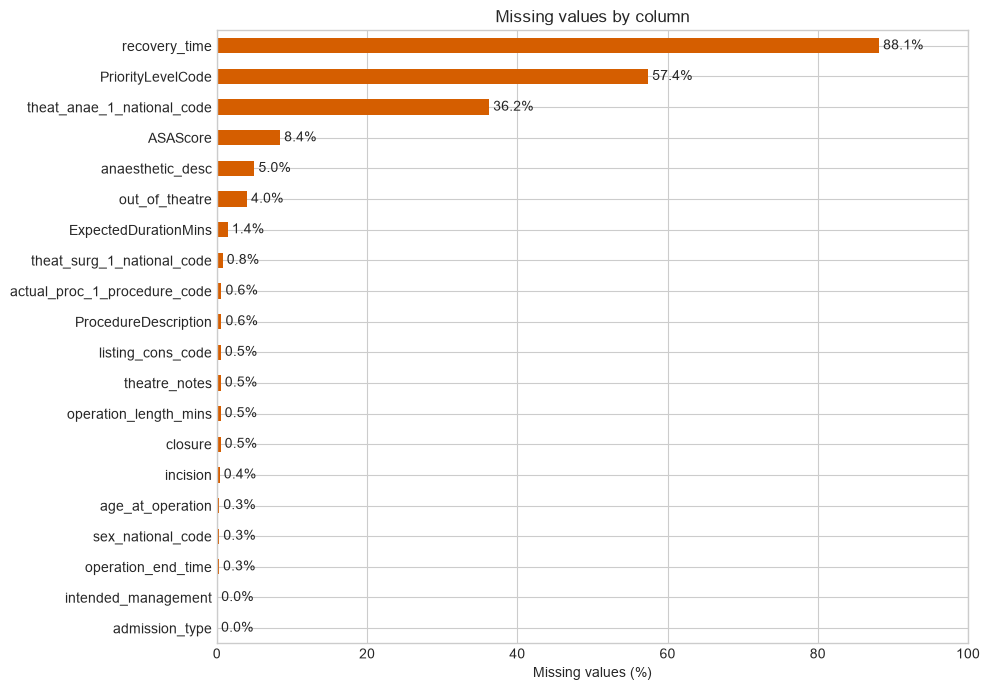

In [172]:
missing_pct = (nbt_smallset_df.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 7))
missing_pct.plot(kind="barh", ax=ax, color=highlight_color)
ax.set_title("Missing values by column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_xlim(0, min(100, missing_pct.max() + 12))

plt.tight_layout()

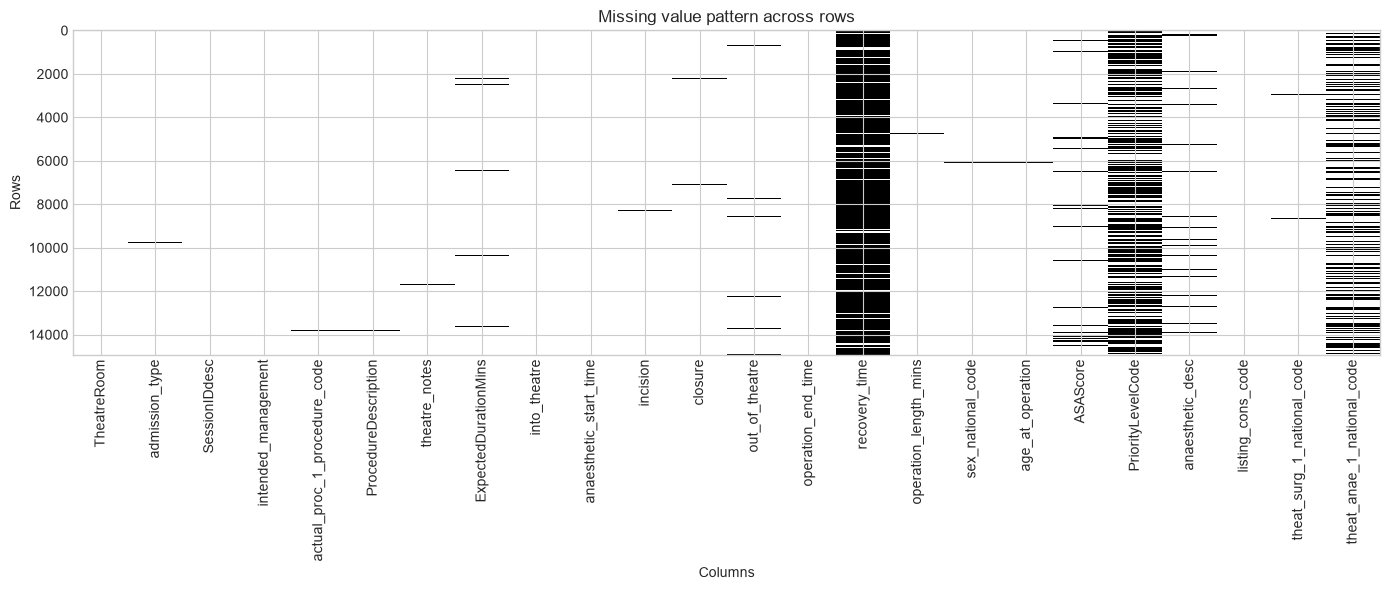

In [173]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(nbt_smallset_df.isna(), aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("Missing value pattern across rows")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
ax.set_xticks(range(len(nbt_smallset_df.columns)))
ax.set_xticklabels(nbt_smallset_df.columns, rotation=90)

plt.tight_layout()

### 9.2 Numeric distributions

These plots show the shape of important numeric columns and help reveal skew, outliers, and impossible values.

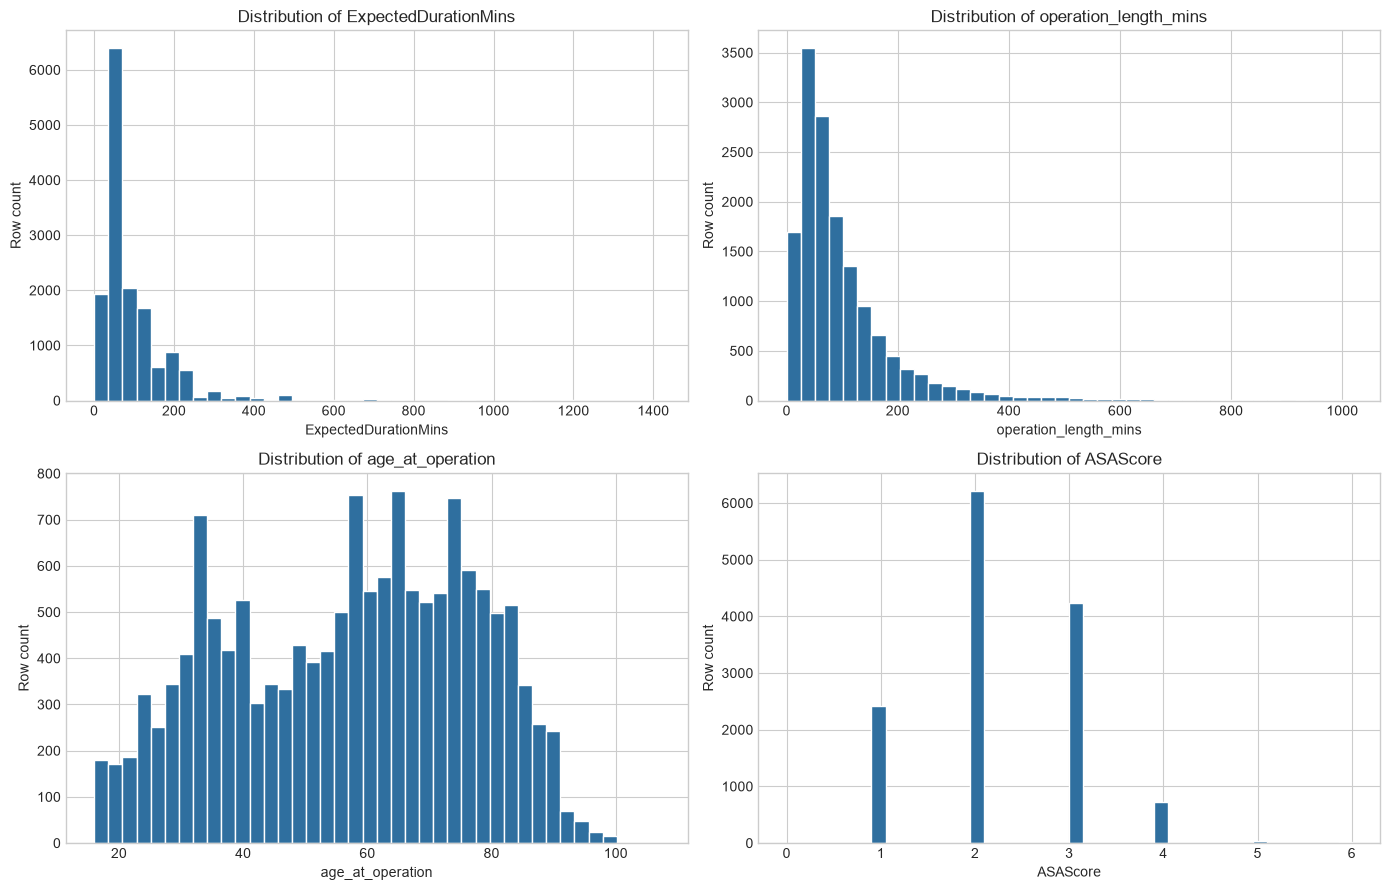

In [174]:
plot_columns = ["ExpectedDurationMins", "operation_length_mins", "age_at_operation", "ASAScore"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, column in zip(axes, plot_columns):
    nbt_smallset_df[column].dropna().plot(kind="hist", bins=40, ax=ax, color=plot_color, edgecolor="white")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Row count")

plt.tight_layout()

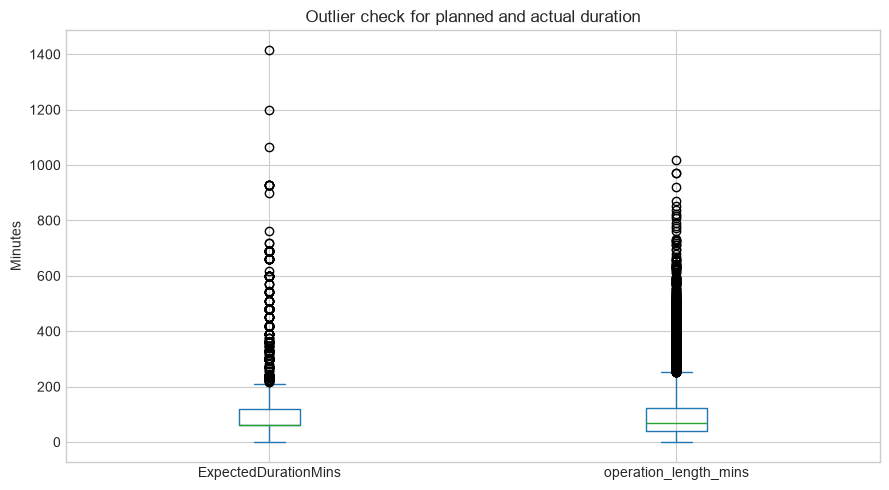

In [175]:
duration_columns = ["ExpectedDurationMins", "operation_length_mins"]

fig, ax = plt.subplots(figsize=(9, 5))
nbt_smallset_df[duration_columns].plot(kind="box", ax=ax)
ax.set_title("Outlier check for planned and actual duration")
ax.set_ylabel("Minutes")

plt.tight_layout()

### 9.3 Categorical distributions

These plots show the most common rooms, procedures, priority codes, anaesthetic types, and ASA scores.

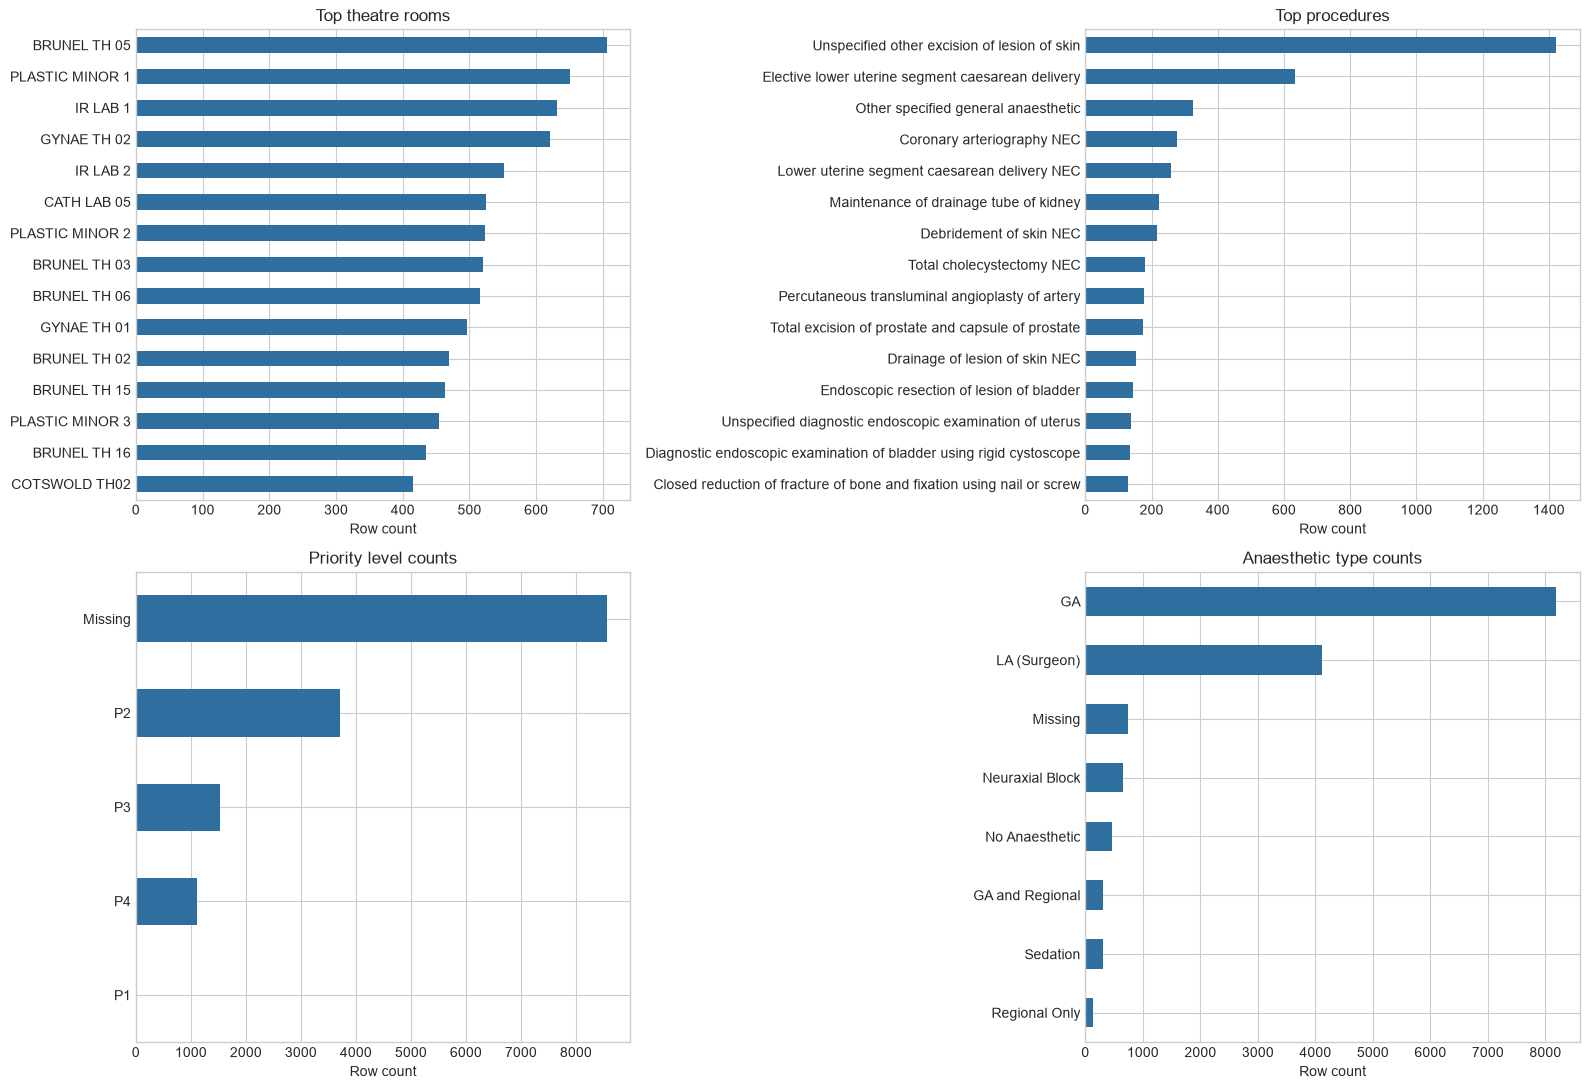

In [176]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

category_plots = {
    "Top theatre rooms": nbt_smallset_df["TheatreRoom"].value_counts().head(15),
    "Top procedures": nbt_smallset_df["ProcedureDescription"].value_counts().head(15),
    "Priority level counts": nbt_smallset_df["PriorityLevelCode"].fillna("Missing").value_counts(),
    "Anaesthetic type counts": nbt_smallset_df["anaesthetic_desc"].fillna("Missing").value_counts(),
}

for ax, (title, values) in zip(axes, category_plots.items()):
    values.sort_values().plot(kind="barh", ax=ax, color=plot_color)
    ax.set_title(title)
    ax.set_xlabel("Row count")
    ax.set_ylabel("")

plt.tight_layout()

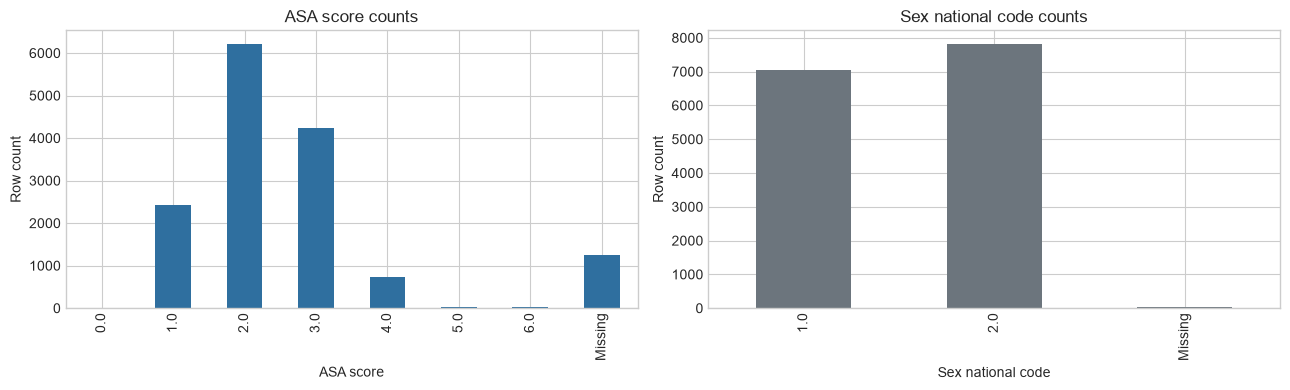

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nbt_smallset_df["ASAScore"].astype("string").fillna("Missing").value_counts().sort_index().plot(kind="bar", ax=axes[0], color=plot_color)
axes[0].set_title("ASA score counts")
axes[0].set_xlabel("ASA score")
axes[0].set_ylabel("Row count")

nbt_smallset_df["sex_national_code"].astype("string").fillna("Missing").value_counts().sort_index().plot(kind="bar", ax=axes[1], color=neutral_color)
axes[1].set_title("Sex national code counts")
axes[1].set_xlabel("Sex national code")
axes[1].set_ylabel("Row count")

plt.tight_layout()

### 9.4 Relationships and performance checks

These visuals compare planned duration with actual operation length and show where duration differs by room or anaesthetic type.

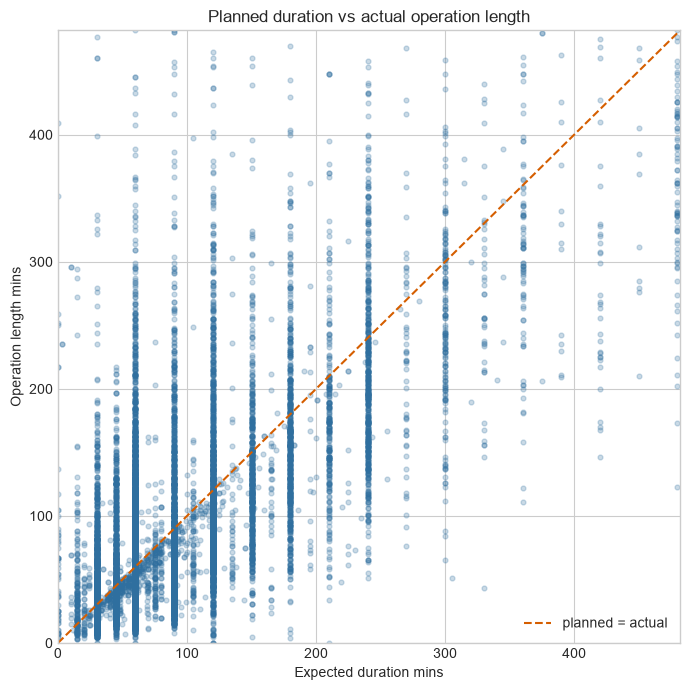

In [178]:
duration_plot_df = nbt_smallset_df[["ExpectedDurationMins", "operation_length_mins"]].dropna()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    duration_plot_df["ExpectedDurationMins"],
    duration_plot_df["operation_length_mins"],
    alpha=0.25,
    s=12,
    color=plot_color,
)

max_duration = duration_plot_df[["ExpectedDurationMins", "operation_length_mins"]].quantile(0.99).max()
ax.plot([0, max_duration], [0, max_duration], color=highlight_color, linestyle="--", label="planned = actual")
ax.set_xlim(0, max_duration)
ax.set_ylim(0, max_duration)
ax.set_title("Planned duration vs actual operation length")
ax.set_xlabel("Expected duration mins")
ax.set_ylabel("Operation length mins")
ax.legend()

plt.tight_layout()

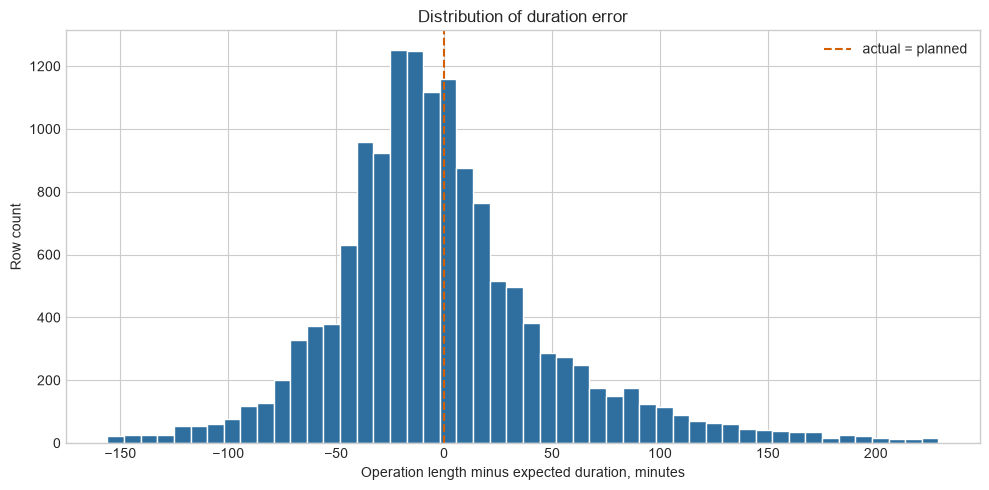

In [179]:
duration_error = nbt_smallset_df["operation_length_mins"] - nbt_smallset_df["ExpectedDurationMins"]
duration_error_trimmed = duration_error[duration_error.between(duration_error.quantile(0.01), duration_error.quantile(0.99))]

fig, ax = plt.subplots(figsize=(10, 5))
duration_error_trimmed.dropna().plot(kind="hist", bins=50, ax=ax, color=plot_color, edgecolor="white")
ax.axvline(0, color=highlight_color, linestyle="--", label="actual = planned")
ax.set_title("Distribution of duration error")
ax.set_xlabel("Operation length minus expected duration, minutes")
ax.set_ylabel("Row count")
ax.legend()

plt.tight_layout()

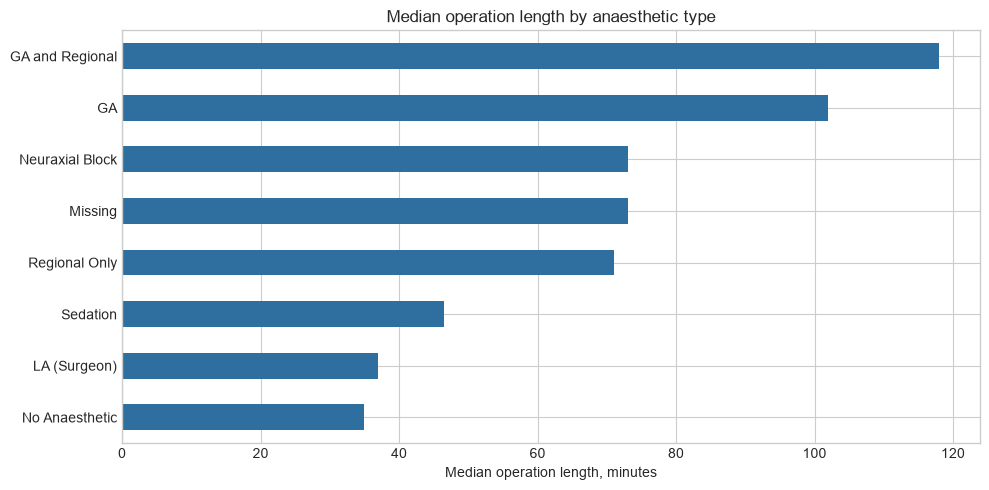

In [180]:
duration_by_anaesthetic = (
    nbt_smallset_df.assign(anaesthetic_desc=nbt_smallset_df["anaesthetic_desc"].fillna("Missing"))
    .groupby("anaesthetic_desc")["operation_length_mins"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
duration_by_anaesthetic.plot(kind="barh", ax=ax, color=plot_color)
ax.set_title("Median operation length by anaesthetic type")
ax.set_xlabel("Median operation length, minutes")
ax.set_ylabel("")

plt.tight_layout()

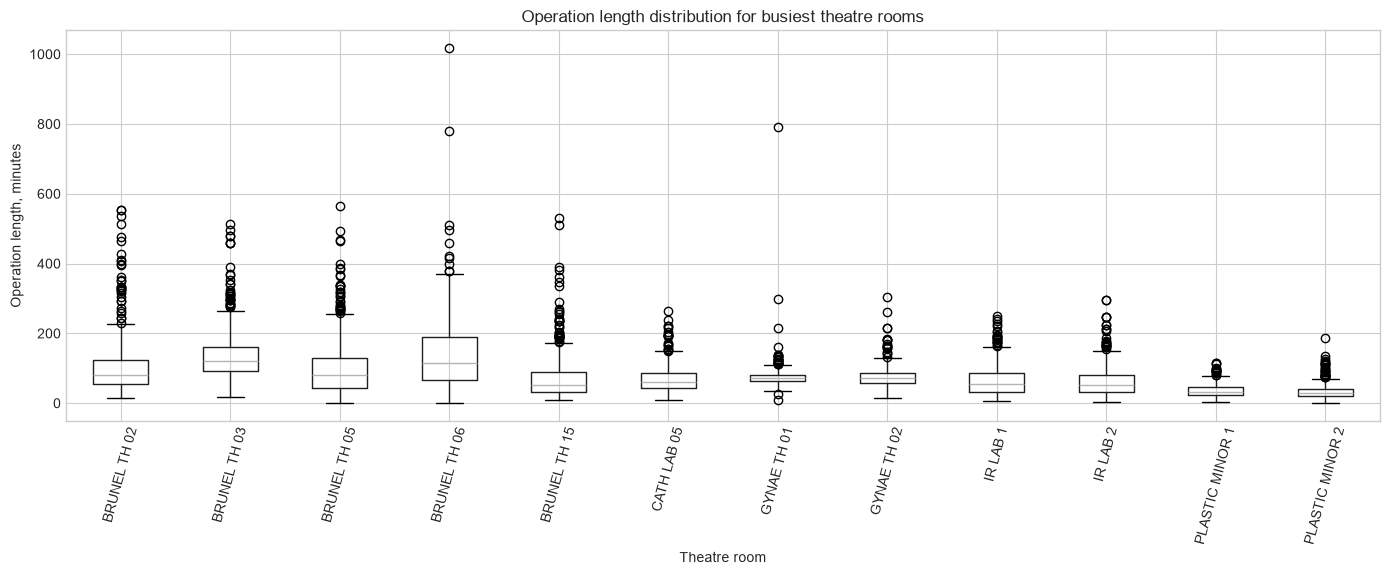

In [181]:
top_rooms = nbt_smallset_df["TheatreRoom"].value_counts().head(12).index
room_duration_df = nbt_smallset_df[nbt_smallset_df["TheatreRoom"].isin(top_rooms)]

fig, ax = plt.subplots(figsize=(14, 6))
room_duration_df.boxplot(column="operation_length_mins", by="TheatreRoom", ax=ax, rot=75)
ax.set_title("Operation length distribution for busiest theatre rooms")
ax.set_xlabel("Theatre room")
ax.set_ylabel("Operation length, minutes")
fig.suptitle("")

plt.tight_layout()

## 10. Initial findings to investigate

- The dataset has 14,918 rows and 24 columns.
- `recovery_time` is mostly missing, so it may not be reliable unless recovery data is optional or captured elsewhere.
- `PriorityLevelCode` and `theat_anae_1_national_code` also have high missingness.
- There are a few exact duplicate rows that should be reviewed before modeling.
- Some duration fields include zeros and very large values, so outlier checks are important.
- Time columns are stored as objects, so they should be converted carefully before time-based feature engineering.
- `theatre_notes` can contain useful information, but it is free text and should be cleaned separately from structured columns.

## Recommended next steps

1. Decide the project target: prediction, cleaning/reporting, delay analysis, theatre utilization, or case-duration modeling.
2. Create a cleaned copy of the dataframe instead of overwriting the raw dataframe.
3. Standardize column names to snake_case.
4. Convert categorical code columns to string/category types.
5. Convert time columns using `pd.to_timedelta` and document how overnight cases should be handled.
6. Decide how to handle missing values column by column.
7. Review duplicate rows and impossible/suspicious duration values before removing anything.